# Part 1 — Data Preprocessing & Exploration

In [ ]:
pip install datasets

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from datasets import load_dataset

# Load the dataset from the Hugging Face Hub
emotion_dataset = load_dataset("dair-ai/emotion")

# Inspect the dataset splits and features
print(emotion_dataset)

# To look at a specific split (e.g., training set)
print("\nFirst example in the training set:")
print(emotion_dataset['train'][0])

# To check the class labels (0: sadness, 1: joy, 2: love, 3: anger, 4: fear, 5: surprise)
print("\nClass labels:")
print(emotion_dataset['train'].features['label'].names)

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

First example in the training set:
{'text': 'i didnt feel humiliated', 'label': 0}

Class labels:
['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [ ]:
from datasets import load_dataset
import pandas as pd

# Load the dataset
dataset = load_dataset("dair-ai/emotion")

# 1. Number of examples per split
print("--- Split Counts ---")
print({split: len(dataset[split]) for split in dataset.keys()})

# Convert training set to pandas for quick analysis
df = dataset['train'].to_pandas()

# 2. Class distribution (Training set)[cite: 1]
print("\n--- Class Distribution (%) ---")
print(df['label'].value_counts(normalize=True).sort_index())

# 3. Text length distribution (Characters & Tokens)[cite: 1]
df['char_len'] = df['text'].str.len()
df['token_len'] = df['text'].str.split().str.len()

print("\n--- Length Statistics ---")
print(df[['char_len', 'token_len']].describe().loc[['mean', 'min', 'max']])

--- Split Counts ---
{'train': 16000, 'validation': 2000, 'test': 2000}

--- Class Distribution (%) ---
label
0    0.291625
1    0.335125
2    0.081500
3    0.134937
4    0.121063
5    0.035750
Name: proportion, dtype: float64

--- Length Statistics ---
        char_len  token_len
mean   96.845812  19.166313
min     7.000000   2.000000
max   300.000000  66.000000


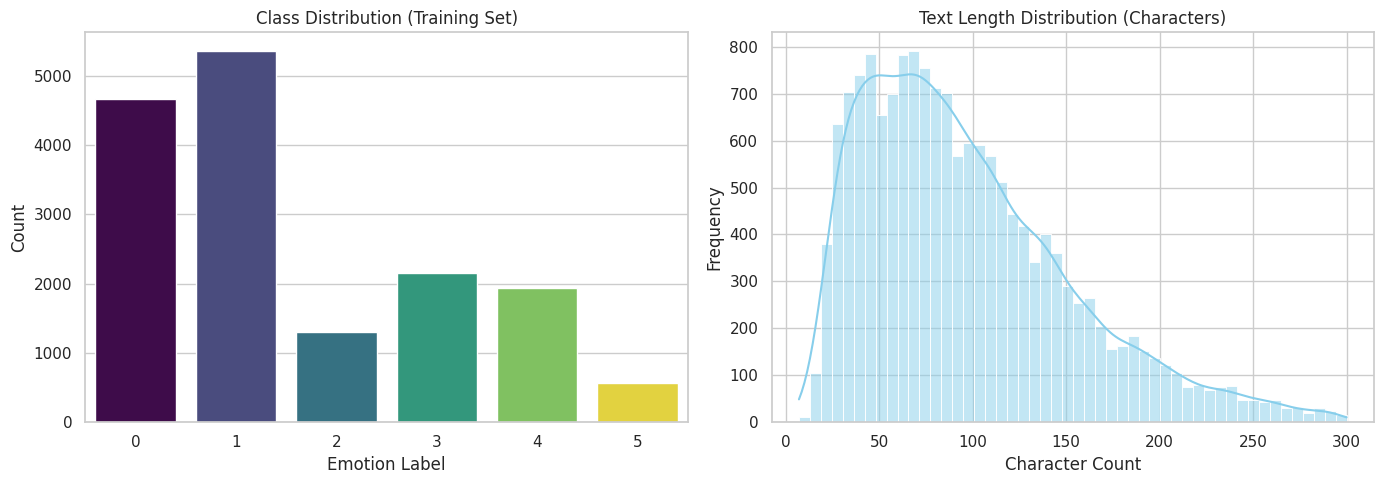

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Visualize class balance - Updated to fix FutureWarning
sns.countplot(data=df, x='label', hue='label', ax=axes[0], palette='viridis', legend=False)
axes[0].set_title('Class Distribution (Training Set)')
axes[0].set_xlabel('Emotion Label')
axes[0].set_ylabel('Count')

# 2. Visualize text length distribution (Characters)
sns.histplot(df['char_len'], bins=50, ax=axes[1], color='skyblue', kde=True)
axes[1].set_title('Text Length Distribution (Characters)')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import string
from datasets import load_dataset

# Load the dataset and convert train split to pandas
dataset = load_dataset("dair-ai/emotion")
df = dataset['train'].to_pandas()

print("--- Text Cleanliness Check ---")

# 1. Check for Uppercase Letters
# Compares the original text to a lowercased version. If they differ, uppercase exists.
uppercase_count = df['text'].apply(lambda x: x != x.lower()).sum()
print(f"Examples containing uppercase letters: {uppercase_count} / {len(df)}")

# 2. Check for Punctuation
# Checks if any character in the text belongs to the string.punctuation set
punct_count = df['text'].apply(lambda x: any(char in string.punctuation for char in x)).sum()
print(f"Examples containing punctuation: {punct_count} / {len(df)}")

# 3. Check for URLs (Common in Twitter data)
url_count = df['text'].str.contains(r'http[s]?://', regex=True).sum()
print(f"Examples containing URLs: {url_count} / {len(df)}")

# 4. Check for User Mentions (e.g., @username)
mention_count = df['text'].str.contains(r'@\w+', regex=True).sum()
print(f"Examples containing @mentions: {mention_count} / {len(df)}")

# 5. Check Maximum Sequence Length (to decide padding/truncation limits)
df['token_length'] = df['text'].apply(lambda x: len(x.split()))
max_len = df['token_length'].max()
percentile_99 = df['token_length'].quantile(0.99)

print("\n--- Sequence Length Analysis ---")
print(f"Absolute Maximum Length (in tokens): {max_len}")
print(f"99th Percentile Length (in tokens): {percentile_99}")

--- Text Cleanliness Check ---
Examples containing uppercase letters: 0 / 16000
Examples containing punctuation: 0 / 16000
Examples containing URLs: 0 / 16000
Examples containing @mentions: 0 / 16000

--- Sequence Length Analysis ---
Absolute Maximum Length (in tokens): 66
99th Percentile Length (in tokens): 52.0


according to this output there is no cleaning needed for the dataset

In [ ]:
import collections
from datasets import load_dataset

# 1. Load the dataset
dataset = load_dataset("dair-ai/emotion")
train_texts = dataset['train']['text']

# 2. Define a simple Vocabulary class
class ManualVocab:
    def __init__(self, min_freq=1):
        self.min_freq = min_freq
        self.itos = {0: "<unk>", 1: "<pad>"} # Index to String
        self.stoi = {"<unk>": 0, "<pad>": 1} # String to Index

    def build_vocabulary(self, sentence_list):
        frequencies = collections.Counter()
        idx = 2

        # Count all words
        for sentence in sentence_list:
            # Lowercase and split just like a basic tokenizer
            tokens = sentence.lower().split()
            frequencies.update(tokens)

        # Add words to vocab if they meet min_freq
        for word, freq in frequencies.items():
            if freq >= self.min_freq:
                self.stoi[word] = idx
                self.itos[idx] = word
                idx += 1

    def __len__(self):
        return len(self.itos)

    def encode(self, text):
        """Converts a string into a list of numerical IDs"""
        tokens = text.lower().split()
        return [self.stoi.get(token, self.stoi["<unk>"]) for token in tokens]

# 3. Initialize and Build
rnn_vocab = ManualVocab(min_freq=2)
rnn_vocab.build_vocabulary(train_texts)

# --- Test the Pipeline ---
sample = "I feel totally fine whatever"
indices = rnn_vocab.encode(sample)

print(f"Vocab Size: {len(rnn_vocab)}")
print(f"Original Text: {sample}")
print(f"Mapped Indices: {indices}")

Vocab Size: 7401
Original Text: I feel totally fine whatever
Mapped Indices: [2, 4, 298, 1024, 981]


In [ ]:
from transformers import AutoTokenizer

# 1. Load the pretrained tokenizer
# This downloads the vocabulary and tokenization rules used during the model's pretraining
model_name = "distilbert-base-uncased" # Or "bert-base-uncased"
transformer_tokenizer = AutoTokenizer.from_pretrained(model_name)

# --- Test the Pretrained Pipeline ---
sample_text = "I feel totally fine whatever"

# The tokenizer handles splitting, adding special tokens ([CLS], [SEP]), and mapping to IDs
encoded = transformer_tokenizer(
    sample_text,
    padding="max_length", # Pads short sequences
    truncation=True,      # Cuts off long sequences
    max_length=64,        # We established this from our Part 1 length analysis
    return_tensors="pt"   # Returns PyTorch tensors
)

print("\n--- Pretrained Transformer Tokenizer ---")
print(f"Original: {sample_text}")
print(f"Tokens: {transformer_tokenizer.convert_ids_to_tokens(encoded['input_ids'][0])}")
print(f"Input IDs: {encoded['input_ids'][0].tolist()}")
print(f"Attention Mask: {encoded['attention_mask'][0].tolist()}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:186: UserWarning: The `resume_download` argument is deprecated and ignored in `hf_hub_download`. Downloads always resume whenever possible.
  `use_auth_token` is passed to a function, the `use_auth_token` value is passed


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


--- Pretrained Transformer Tokenizer ---
Original: I feel totally fine whatever
Tokens: ['[CLS]', 'i', 'feel', 'totally', 'fine', 'whatever', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
Input IDs: [101, 1045, 2514, 6135, 2986, 3649, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

# Part 2 — Baseline: From-Scratch RNN Classifier

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class EmotionDataset(Dataset):
  def __init__(self, hf_dataset_split, vocab, max_len=64):
    self.texts = hf_dataset_split['text']
    self.labels = hf_dataset_split['label']
    self.vocab = vocab
    self.max_len = max_len
    self.pad_idx = vocab.stoi["<pad>"]

  def __len__(self):
    return len(self.texts)

  def __getitem__(self, idx):
    text = self.texts[idx]
    label = self.labels[idx]
    encoded_text = self.vocab.encode(text)

    if len(encoded_text) > self.max_len:
      encoded_text = encoded_text[:self.max_len]

    pad_length = self.max_len - len(encoded_text)
    encoded_text = encoded_text + [self.pad_idx] * pad_length

    text_tensor = torch.LongTensor(encoded_text)
    # Removed brackets around label to ensure it's a 0D tensor (scalar)
    # When batched by DataLoader, this becomes a 1D tensor [batch_size]
    label_tensor = torch.tensor(label, dtype=torch.long)

    return text_tensor, label_tensor

MAX_LEN = 64
BATCH_SIZE = 64

train_dataset = EmotionDataset(dataset['train'], rnn_vocab, max_len=MAX_LEN)
val_dataset = EmotionDataset(dataset['validation'], rnn_vocab, max_len=MAX_LEN)
test_dataset = EmotionDataset(dataset['test'], rnn_vocab, max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

sample_texts, sample_labels = next(iter(train_loader))
print(f"Batch Text Shape: {sample_texts.shape}")
print(f"Batch Labels Shape: {sample_labels.shape}")

Batch Text Shape: torch.Size([64, 64])
Batch Labels Shape: torch.Size([64])


In [ ]:
import torch.nn as nn
import torch.optim as optim

class EmotioanLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, num_layers=2):
        super().__init__()

        # embedding layer
        self.Embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=1)

        # 2 recurrent layers
        self.lstm = nn.LSTM(
            input_size= embedding_dim,
            hidden_size= hidden_dim,
            num_layers= num_layers,
            batch_first= True,
            dropout=0.5,
            bidirectional=True
        )

        # The Dense Classification Head
        self.fc = nn.Linear(hidden_dim*2, output_dim)

    def forward(self, text):
        embedded = self.Embedding(text)
        lstm_out, _ = self.lstm(embedded)
        final_feature_map, _ = torch.max(lstm_out, dim=1)
        output = self.fc(final_feature_map)
        return output

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EmotioanLSTM(
    vocab_size=len(rnn_vocab),
    embedding_dim=100,
    hidden_dim=128,
    output_dim=6,
    num_layers=2
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# --- Sanity Check ---
print(model)
print(f"The model has {sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable parameters.")

EmotioanLSTM(
  (Embedding): Embedding(7401, 100, padding_idx=1)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=256, out_features=6, bias=True)
)
The model has 1,372,426 trainable parameters.


In [ ]:
import time
import torch

EPOCHS = 10
train_losses = []
val_losses = []

print("Starting BiLSTM Training...")
# 1. Start the global timer for the entire training process
total_start_time = time.time()

for epoch in range(EPOCHS):
    start_time = time.time()
    model.train()
    epoch_train_loss = 0

    for batch_texts, batch_labels in train_loader:
        # Move data to GPU
        batch_texts = batch_texts.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()
        output = model(batch_texts)
        loss = criterion(output, batch_labels.squeeze())
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Validation Phase ---
    model.eval()
    epoch_val_loss = 0

    with torch.no_grad():
        for batch_texts, batch_labels in val_loader:
            # Move data to GPU
            batch_texts = batch_texts.to(device)
            batch_labels = batch_labels.to(device)

            logits = model(batch_texts)
            loss = criterion(logits, batch_labels.squeeze())
            epoch_val_loss += loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    end_time = time.time()
    duration = end_time - start_time
    epoch_mins = int(duration / 60)
    epoch_secs = int(duration % 60)

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {avg_train_loss:.4f} | Val. Loss: {avg_val_loss:.4f}')

# 2. Stop the global timer and calculate total duration
total_end_time = time.time()
total_training_time = total_end_time - total_start_time

print("-" * 50)
print(f"Total Training Time: {total_training_time / 60:.2f} minutes")

Starting BiLSTM Training...
Epoch: 01 | Epoch Time: 0m 9s
	Train Loss: 1.4420 | Val. Loss: 1.0310
Epoch: 02 | Epoch Time: 0m 8s
	Train Loss: 0.6220 | Val. Loss: 0.3957
Epoch: 03 | Epoch Time: 0m 8s
	Train Loss: 0.2713 | Val. Loss: 0.2668
Epoch: 04 | Epoch Time: 0m 8s
	Train Loss: 0.1696 | Val. Loss: 0.2187
Epoch: 05 | Epoch Time: 0m 8s
	Train Loss: 0.1296 | Val. Loss: 0.2521
Epoch: 06 | Epoch Time: 0m 8s
	Train Loss: 0.1084 | Val. Loss: 0.1900
Epoch: 07 | Epoch Time: 0m 8s
	Train Loss: 0.0947 | Val. Loss: 0.2200
Epoch: 08 | Epoch Time: 0m 8s
	Train Loss: 0.0880 | Val. Loss: 0.1933
Epoch: 09 | Epoch Time: 0m 8s
	Train Loss: 0.0805 | Val. Loss: 0.1950
Epoch: 10 | Epoch Time: 0m 8s
	Train Loss: 0.0723 | Val. Loss: 0.2040
--------------------------------------------------
Total Training Time: 1.43 minutes


In [ ]:
import time
import torch

model.eval() # Turn off dropout for inference

with torch.no_grad():
    # Wait for any lingering GPU tasks before starting the clock
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_inference_time = time.time()

    for batch_texts, batch_labels in test_loader:
        # Move data to GPU
        batch_texts = batch_texts.to(device)

        # Forward pass
        logits = model(batch_texts)
        predictions = logits.argmax(dim=1)

    # Wait until the GPU has finished all predictions
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    end_inference_time = time.time()

# The exact same print statement from your Transformer code
print(f"Total Inference Time for Test Set: {end_inference_time - start_inference_time:.2f} seconds")

Total Inference Time for Test Set: 0.58 seconds


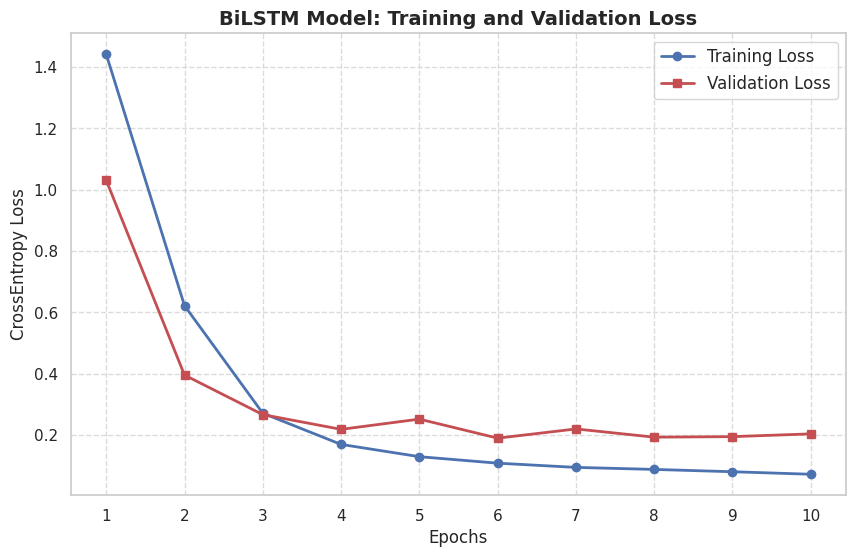

In [ ]:
import matplotlib.pyplot as plt

# We calculate the total number of epochs based on the length of your loss lists
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))

# 'b-o' creates a blue line with circular markers for training
plt.plot(epochs, train_losses, 'b-o', label='Training Loss', linewidth=2)

# 'r-s' creates a red line with square markers for validation
plt.plot(epochs, val_losses, 'r-s', label='Validation Loss', linewidth=2)

# Adding titles and labels
plt.title('BiLSTM Model: Training and Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('CrossEntropy Loss', fontsize=12)

# This forces the X-axis to display every single integer epoch number
plt.xticks(epochs)

# Add a legend and a grid for readability
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Display the final plot
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
import torch

# 1. Prepare to collect predictions
all_preds = []
all_true = []

# Put the model in evaluation mode (turns off dropout)
model.eval()

# 2. Run the test set through the model
with torch.no_grad():
    for batch_texts, batch_labels in test_loader:

        # --> Move data to the GPU <--
        batch_texts = batch_texts.to(device)
        batch_labels = batch_labels.to(device)

        output = model(batch_texts)

        # Get the predicted class (index of the highest score)
        predictions = output.argmax(dim=1)

        # --> Move tensors back to CPU and convert to standard Python lists <--
        all_preds.extend(predictions.cpu().tolist())
        all_true.extend(batch_labels.squeeze().cpu().tolist())

# 3. Calculate Metrics
test_accuracy = accuracy_score(all_true, all_preds)
macro_f1 = f1_score(all_true, all_preds, average='macro')
per_class_f1 = f1_score(all_true, all_preds, average=None)

# Your emotion labels in the correct order
emotion_labels = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

# 4. Print the final results
print("=== FINAL BiLSTM EVALUATION (GPU) ===")
print(f"Overall Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Overall Macro F1 Score: {macro_f1:.4f}\n")

print("=== PER-CLASS F1 SCORES ===")
for label, score in zip(emotion_labels, per_class_f1):
    print(f"{label.capitalize():>10}: {score:.4f}")

print("\n=== DETAILED CLASSIFICATION REPORT ===")
print(classification_report(all_true, all_preds, target_names=emotion_labels))

=== FINAL BiLSTM EVALUATION (GPU) ===
Overall Test Accuracy: 90.70%
Overall Macro F1 Score: 0.8706

=== PER-CLASS F1 SCORES ===
   Sadness: 0.9493
       Joy: 0.9238
      Love: 0.7966
     Anger: 0.9101
      Fear: 0.8776
  Surprise: 0.7662

=== DETAILED CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     sadness       0.95      0.95      0.95       581
         joy       0.95      0.90      0.92       695
        love       0.72      0.89      0.80       159
       anger       0.92      0.90      0.91       275
        fear       0.91      0.85      0.88       224
    surprise       0.67      0.89      0.77        66

    accuracy                           0.91      2000
   macro avg       0.85      0.90      0.87      2000
weighted avg       0.91      0.91      0.91      2000



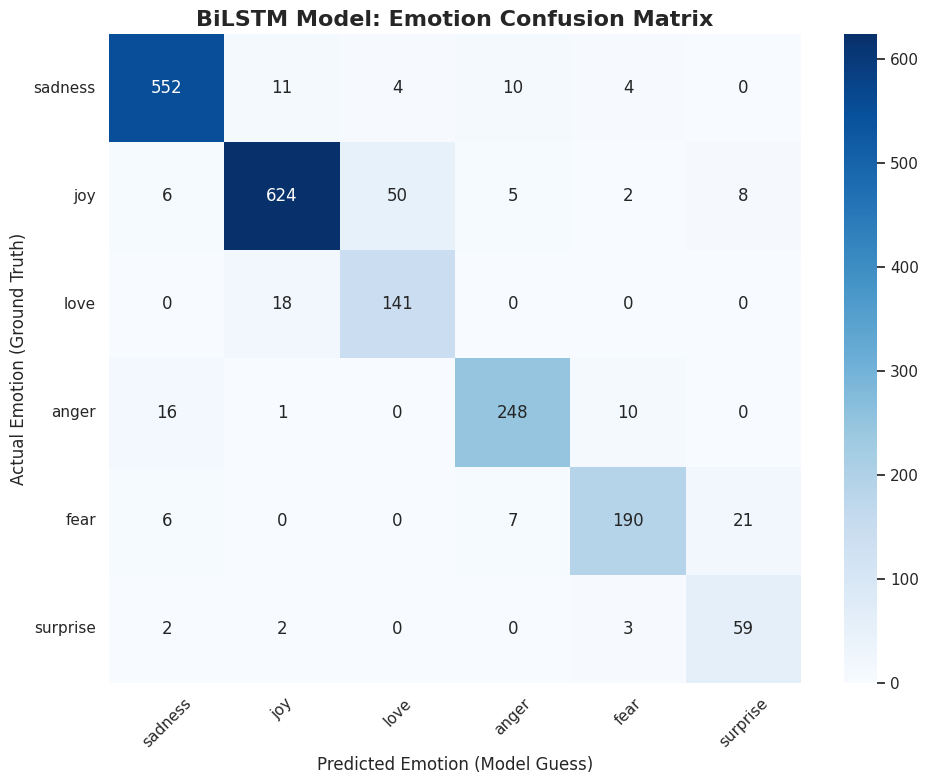

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate the raw confusion matrix numbers
cm = confusion_matrix(all_true, all_preds)

# 2. Set up the canvas size
plt.figure(figsize=(10, 8))

# 3. Create the heatmap
# annot=True puts the numbers in the boxes
# fmt='d' ensures the numbers are integers, not scientific notation
# cmap='Blues' gives it a clean, professional color scheme
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels,
            yticklabels=emotion_labels)

# 4. Add titles and labels
plt.title('BiLSTM Model: Emotion Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual Emotion (Ground Truth)', fontsize=12)
plt.xlabel('Predicted Emotion (Model Guess)', fontsize=12)

# 5. Rotate the x-axis labels slightly so they are easier to read
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# 6. Display the plot
plt.tight_layout()
plt.show()

In [ ]:
import torch

# 1. The Translator Function for BiLSTM (GPU Version)
def predict_emotion(sentence):
    model.eval() # Turn off dropout

    # Process text using the vocabulary from Part 2
    words = sentence.lower().split()
    unk_id = rnn_vocab.stoi.get('<unk>', 0)
    numericalized_words = [rnn_vocab.stoi.get(word, unk_id) for word in words]


    # .unsqueeze(0) adds the batch dimension
    tensor_text = torch.tensor(numericalized_words, dtype=torch.long).unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        logits = model(tensor_text)
        prediction_index = logits.argmax(dim=1).item()

    # Map index to word
    emotion_labels = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
    return emotion_labels[prediction_index]

# 2. Single Execution Logic
print("🤖 BiLSTM System Ready")
user_input = input("Enter a sentence for BiLSTM emotion analysis: ")

# Execute prediction once
if user_input.strip():
    prediction = predict_emotion(user_input)
    print(f"Model: [{prediction.upper()}]")

print("\nProcess complete. Execution finished.")

🤖 BiLSTM System Ready


Enter a sentence for BiLSTM emotion analysis:  I’m nervous about the interview, but also hopeful.


Model: [FEAR]

Process complete. Execution finished.


# Part 3 — Transfer Learning: Fine-Tuned Transformer

In [ ]:
# 1. Your existing initialization
model_name = "distilbert-base-uncased"
transformer_tokenizer = AutoTokenizer.from_pretrained(model_name)

# 2. Define a mapping function for the datasets
def tokenize_function(examples):
    return transformer_tokenizer(
        examples["text"],       # Replace "text" with your actual column name if it differs
        padding="max_length",
        truncation=True,
        max_length=64,
    )

# 3. Apply the mapping function to your dataset splits
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# 4. Format the datasets to output PyTorch tensors
tokenized_datasets.set_format("torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
import torch
from transformers import AutoModelForSequenceClassification

# 1. Define the model
model_name = "distilbert-base-uncased"

# 2. Load the model and replace the classification head for 6 classes
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=6
)

# 3. Define the device (This will default to the first GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 4. Move the model directly to the hardware
# We removed the nn.DataParallel block so the model stays as a single instance
model.to(device)

print(f"Model successfully loaded on: {device}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model successfully loaded on: cuda


In [ ]:
from torch.utils.data import DataLoader
from torch.optim import AdamW  # <--- Import from torch.optim instead
from transformers import get_linear_schedule_with_warmup
import time

# 1. Create DataLoaders
train_loader = DataLoader(tokenized_datasets["train"], batch_size=32, shuffle=True)
val_loader = DataLoader(tokenized_datasets["validation"], batch_size=32)
test_loader = DataLoader(tokenized_datasets["test"], batch_size=32)

# 2. Optimizer & Scheduler
optimizer = AdamW(model.parameters(), lr=5e-5)

epochs = 3
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

# 3. Loss Function
criterion = torch.nn.CrossEntropyLoss()

In [ ]:
train_losses = []
val_losses = []

print("Starting Training...")
start_train_time = time.time()

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for batch in train_loader:
        # Move batch to GPU
        b_input_ids = batch['input_ids'].to(device)
        b_input_mask = batch['attention_mask'].to(device)
        b_labels = batch['label'].to(device)

        # Clear gradients
        model.zero_grad()

        # Forward pass
        outputs = model(b_input_ids, attention_mask=b_input_mask)
        loss = criterion(outputs.logits, b_labels)

        total_train_loss += loss.item()

        # Backward pass (Backpropagation)
        loss.backward()

        # Clip gradients (prevents "exploding gradients" in Transformers)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # Update weights and learning rate
        optimizer.step()
        scheduler.step()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Validation Phase ---
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            b_input_ids = batch['input_ids'].to(device)
            b_input_mask = batch['attention_mask'].to(device)
            b_labels = batch['label'].to(device)

            outputs = model(b_input_ids, attention_mask=b_input_mask)
            loss = criterion(outputs.logits, b_labels)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f}")

end_train_time = time.time()
total_training_time = end_train_time - start_train_time
print(f"Total Training Time: {total_training_time/60:.2f} minutes")

Starting Training...
Epoch 1: Train Loss 0.4439 | Val Loss 0.1851
Epoch 2: Train Loss 0.1359 | Val Loss 0.1461
Epoch 3: Train Loss 0.0862 | Val Loss 0.1377
Total Training Time: 4.69 minutes


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
all_preds = []
all_labels = []

start_inference_time = time.time()

with torch.no_grad():
    for batch in test_loader:
        b_input_ids = batch['input_ids'].to(device)
        b_input_mask = batch['attention_mask'].to(device)
        b_labels = batch['label'].to(device)

        outputs = model(b_input_ids, attention_mask=b_input_mask)

        logits = outputs.logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()

        all_preds.extend(np.argmax(logits, axis=1))
        all_labels.extend(label_ids)

end_inference_time = time.time()
print(f"Total Inference Time for Test Set: {end_inference_time - start_inference_time:.2f} seconds")

Total Inference Time for Test Set: 3.67 seconds


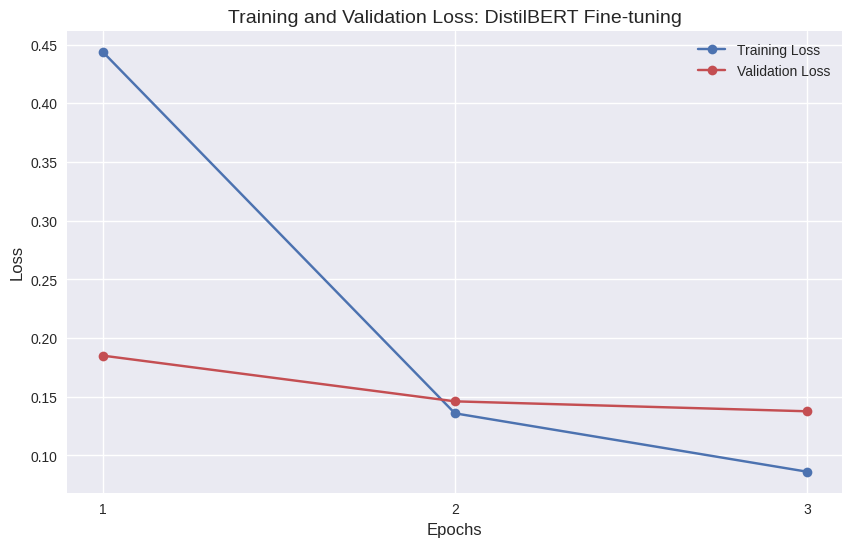

In [ ]:
import matplotlib.pyplot as plt

# 1. Set the style and figure size
plt.style.use('seaborn-v0_8') # A clean, professional look
plt.figure(figsize=(10, 6))

# 2. Plot the data
# We use range(1, epochs + 1) for the x-axis so it shows '1, 2, 3' instead of '0, 1, 2'
epochs_range = range(1, len(train_losses) + 1)

plt.plot(epochs_range, train_losses, 'b-o', label='Training Loss')
plt.plot(epochs_range, val_losses, 'r-o', label='Validation Loss')

# 3. Add metadata
plt.title('Training and Validation Loss: DistilBERT Fine-tuning', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(epochs_range) # Ensure we only show integer epoch numbers
plt.legend()
plt.grid(True)

# 4. Save and show
plt.savefig('loss_curves.png')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
import torch

# 1. Prepare to collect predictions
all_preds = []
all_true = []

# Put the model in evaluation mode (turns off dropout)
model.eval()

# 2. Run the test set through the model
with torch.no_grad():
    for batch in test_loader:
        # Move batch inputs to the GPU
        b_input_ids = batch['input_ids'].to(device)
        b_input_mask = batch['attention_mask'].to(device)
        b_labels = batch['label'].to(device)

        # Forward pass (Transformers require both input_ids and attention_mask)
        outputs = model(b_input_ids, attention_mask=b_input_mask)

        # Get the predicted class from the logits
        predictions = outputs.logits.argmax(dim=1)

        # Move tensors back to CPU and convert to standard Python lists
        all_preds.extend(predictions.cpu().tolist())
        all_true.extend(b_labels.cpu().tolist())

# 3. Calculate Metrics
test_accuracy = accuracy_score(all_true, all_preds)
macro_f1 = f1_score(all_true, all_preds, average='macro')
per_class_f1 = f1_score(all_true, all_preds, average=None)

# Your emotion labels in the correct order
emotion_labels = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

# 4. Print the final results
print("=== FINAL DISTILBERT EVALUATION (GPU) ===")
print(f"Overall Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Overall Macro F1 Score: {macro_f1:.4f}\n")

print("=== PER-CLASS F1 SCORES ===")
for label, score in zip(emotion_labels, per_class_f1):
    print(f"{label.capitalize():>10}: {score:.4f}")

print("\n=== DETAILED CLASSIFICATION REPORT ===")
print(classification_report(all_true, all_preds, target_names=emotion_labels))

=== FINAL DISTILBERT EVALUATION (GPU) ===
Overall Test Accuracy: 92.90%
Overall Macro F1 Score: 0.8874

=== PER-CLASS F1 SCORES ===
   Sadness: 0.9659
       Joy: 0.9444
      Love: 0.8280
     Anger: 0.9338
      Fear: 0.9022
  Surprise: 0.7500

=== DETAILED CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     sadness       0.98      0.95      0.97       581
         joy       0.94      0.95      0.94       695
        love       0.84      0.82      0.83       159
       anger       0.92      0.95      0.93       275
        fear       0.90      0.91      0.90       224
    surprise       0.77      0.73      0.75        66

    accuracy                           0.93      2000
   macro avg       0.89      0.88      0.89      2000
weighted avg       0.93      0.93      0.93      2000



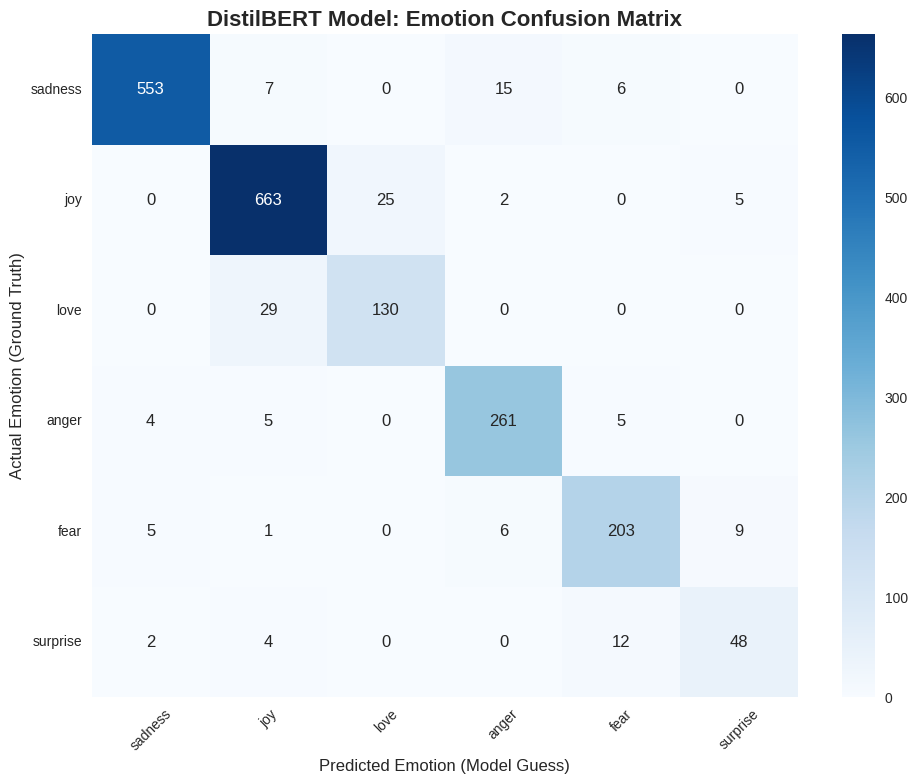

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate the raw confusion matrix numbers
# This uses all_true and all_preds from the evaluation we just ran
cm = confusion_matrix(all_true, all_preds)

# 2. Set up the canvas size
plt.figure(figsize=(10, 8))

# 3. Create the heatmap
# annot=True puts the numbers in the boxes
# fmt='d' ensures the numbers are integers, not scientific notation
# cmap='Blues' gives it a clean, professional color scheme
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels,
            yticklabels=emotion_labels)

# 4. Add titles and labels
# Updated to reflect the DistilBERT transformer model used in this section
plt.title('DistilBERT Model: Emotion Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual Emotion (Ground Truth)', fontsize=12)
plt.xlabel('Predicted Emotion (Model Guess)', fontsize=12)

# 5. Rotate the x-axis labels slightly so they are easier to read
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# 6. Display the plot
plt.tight_layout()
plt.show()

In [ ]:
import torch

# 1. The Translator Function for the Transformer
def predict_emotion(sentence):
    model.eval() # Ensure dropout is turned off for inference

    # Process text using the Hugging Face tokenizer
    encoded = transformer_tokenizer(
        sentence,
        padding="max_length",
        truncation=True,
        max_length=64,
        return_tensors="pt"
    )

    # Move the tensors to the GPU
    input_ids = encoded['input_ids'].to(device)
    attention_mask = encoded['attention_mask'].to(device)

    # Predict
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        prediction_index = outputs.logits.argmax(dim=1).item()

    emotion_labels = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
    return emotion_labels[prediction_index]

# 2. Single Execution Logic
print("🤖 DistilBERT System Ready!")
user_input = input("Enter a sentence for emotion analysis: ")

# Execute prediction once
if user_input.strip():
    prediction = predict_emotion(user_input)
    print(f"Model: [{prediction.upper()}]")

🤖 DistilBERT System Ready!


Enter a sentence for emotion analysis:  i was shocked about what happened to him


Model: [SURPRISE]


# Part 4 — LLM Prompting (No Training)

In [ ]:
!pip install --no-cache-dir bitsandbytes==0.46.1 transformers==4.41.2 accelerate huggingface_hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 187.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 331.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 249.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 277.1 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

llm_model_id = "microsoft/Phi-3-mini-4k-instruct"

# 1. Load Tokenizer
llm_tokenizer = AutoTokenizer.from_pretrained(llm_model_id)

# 2. Configure Quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4"
)

# 3. Load Model (Now with 'eager' attention to stop the warnings)
llm_model = AutoModelForCausalLM.from_pretrained(
    llm_model_id,
    quantization_config=bnb_config,
    device_map="auto",
    attn_implementation="eager"
)

print("Model loaded successfully!")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Model loaded successfully!


Starting Zero-Shot Inference on Test Set...


Zero-Shot:   0%|          | 0/2000 [00:00<?, ?it/s]


1. EXAMPLE PROMPTS & RAW OUTPUTS (First 3)
--- Example 1 ---
PROMPT:
<|system|>
You are an expert emotion classifier. Classify the text into EXACTLY ONE of these six emotions: sadness, joy, love, anger, fear, or surprise. Output ONLY the emotion word.<|end|>
<|user|>
Text: "im feeling rather rotten so im not very ambitious right now"<|end|>
<|assistant|>

RAW OUTPUT: [sadness]

--- Example 2 ---
PROMPT:
<|system|>
You are an expert emotion classifier. Classify the text into EXACTLY ONE of these six emotions: sadness, joy, love, anger, fear, or surprise. Output ONLY the emotion word.<|end|>
<|user|>
Text: "im updating my blog because i feel shitty"<|end|>
<|assistant|>

RAW OUTPUT: [sadness]

--- Example 3 ---
PROMPT:
<|system|>
You are an expert emotion classifier. Classify the text into EXACTLY ONE of these six emotions: sadness, joy, love, anger, fear, or surprise. Output ONLY the emotion word.<|end|>
<|user|>
Text: "i never make her separate from me because i don t ever want her to

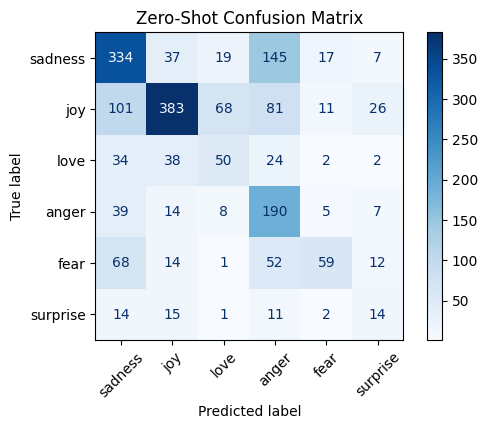

In [ ]:
# --- Zero-Shot Prompting Test ---

import time
import re
import torch
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Setup dataset and mapping
test_data = dataset["test"]
id_to_label = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}
label_to_id = {v: k for k, v in id_to_label.items()}

true_labels, predicted_labels = [], []
example_prompts, example_outputs = [], []

print("Starting Zero-Shot Inference on Test Set...")
start_time = time.time() # Start Inference Timer

for i, item in enumerate(tqdm(test_data, desc="Zero-Shot")):
    sample_text = item['text']
    true_label_id = item['label']

    # ZERO-SHOT PROMPT
    prompt = f"""<|system|>
You are an expert emotion classifier. Classify the text into EXACTLY ONE of these six emotions: sadness, joy, love, anger, fear, or surprise. Output ONLY the emotion word.<|end|>
<|user|>
Text: "{sample_text}"<|end|>
<|assistant|>"""

    inputs = llm_tokenizer(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = llm_model.generate(
            **inputs,
            max_new_tokens=5,
            temperature=0.0,
            do_sample=False,
            pad_token_id=llm_tokenizer.eos_token_id
        )

    input_length = inputs.input_ids.shape[1]
    raw_output = llm_tokenizer.decode(outputs[0][input_length:], skip_special_tokens=True).strip().lower()
    clean_output = re.sub(r'[^\w\s]', '', raw_output)
    pred_id = label_to_id.get(clean_output, -1)

    true_labels.append(true_label_id)
    predicted_labels.append(pred_id)

    # Save the first 3 examples for the notebook display requirement
    if i < 3:
        example_prompts.append(prompt)
        example_outputs.append(raw_output)

end_time = time.time() # End Inference Timer
inference_time = end_time - start_time

# ----------------- REPORTING OUTPUTS -----------------
print("\n" + "="*50)
print("1. EXAMPLE PROMPTS & RAW OUTPUTS (First 3)")
print("="*50)
for idx in range(3):
    print(f"--- Example {idx+1} ---")
    print(f"PROMPT:\n{example_prompts[idx]}")
    print(f"\nRAW OUTPUT: [{example_outputs[idx]}]\n")

print("="*50)
print("2. METRICS & INFERENCE TIME")
print("="*50)
print(f"Total Inference Time: {inference_time:.2f} seconds")
print(f"Accuracy: {accuracy_score(true_labels, predicted_labels):.4f}")
print(f"Macro F1: {f1_score(true_labels, predicted_labels, average='macro'):.4f}")

print("\n" + "="*50)
print("3. CONFUSION MATRIX")
print("="*50)
cm_labels = [0, 1, 2, 3, 4, 5]
display_names = ["sadness", "joy", "love", "anger", "fear", "surprise"]
cm = confusion_matrix(true_labels, predicted_labels, labels=cm_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_names)
fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(cmap="Blues", xticks_rotation=45, ax=ax)
plt.title("Zero-Shot Confusion Matrix")
plt.show()


🚀 STARTING 3-SHOT EVALUATION


3-Shot Progress:   0%|          | 0/2000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:515: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(



--- 1. EXAMPLE PROMPTS & RAW OUTPUTS (First 3) ---

[Example 1]
PROMPT:
<|system|>
You are an expert emotion classifier. Classify the text into EXACTLY ONE of these six emotions: sadness, joy, love, anger, fear, or surprise. Output ONLY the emotion word.<|end|>
<|user|>
Text: "i feel completely defeated"
Emotion: sadness

Text: "i just got engaged to my best friend"
Emotion: joy

Text: "i am terrified of the dark"
Emotion: fear

Text: "im feeling rather rotten so im not very ambitious right now"
Emotion:<|end|>
<|assistant|>
RAW OUTPUT: [sadness]

[Example 2]
PROMPT:
<|system|>
You are an expert emotion classifier. Classify the text into EXACTLY ONE of these six emotions: sadness, joy, love, anger, fear, or surprise. Output ONLY the emotion word.<|end|>
<|user|>
Text: "i feel completely defeated"
Emotion: sadness

Text: "i just got engaged to my best friend"
Emotion: joy

Text: "i am terrified of the dark"
Emotion: fear

Text: "im updating my blog because i feel shitty"
Emotion:<|end|

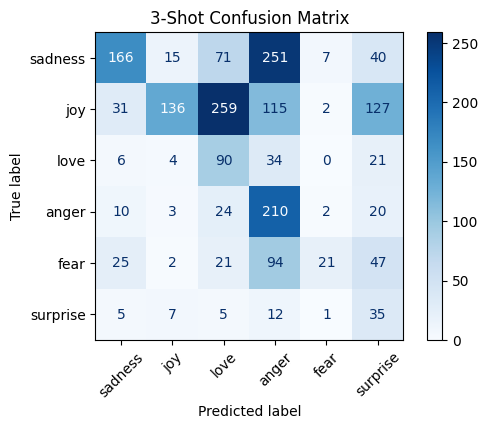


🚀 STARTING 8-SHOT EVALUATION


8-Shot Progress:   0%|          | 0/2000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:515: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(



--- 1. EXAMPLE PROMPTS & RAW OUTPUTS (First 3) ---

[Example 1]
PROMPT:
<|system|>
You are an expert emotion classifier. Classify the text into EXACTLY ONE of these six emotions: sadness, joy, love, anger, fear, or surprise. Output ONLY the emotion word.<|end|>
<|user|>
Text: "i feel completely defeated"
Emotion: sadness

Text: "i just got engaged to my best friend"
Emotion: joy

Text: "i am terrified of the dark"
Emotion: fear

Text: "i am so mad at how they treated me"
Emotion: anger

Text: "i care about her more than anything"
Emotion: love

Text: "wow i did not expect to see you here"
Emotion: surprise

Text: "this is the best day of my life"
Emotion: joy

Text: "i miss my grandfather so much"
Emotion: sadness

Text: "im feeling rather rotten so im not very ambitious right now"
Emotion:<|end|>
<|assistant|>
RAW OUTPUT: [sadness]

[Example 2]
PROMPT:
<|system|>
You are an expert emotion classifier. Classify the text into EXACTLY ONE of these six emotions: sadness, joy, love, anger,

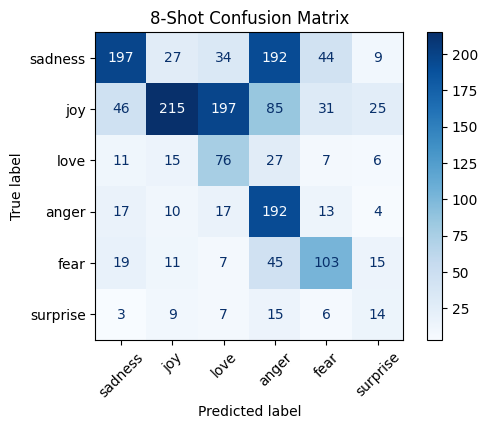

In [ ]:
import time
import re
import torch
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Define our Few-Shot Examples manually
examples_3_shot = """Text: "i feel completely defeated"
Emotion: sadness

Text: "i just got engaged to my best friend"
Emotion: joy

Text: "i am terrified of the dark"
Emotion: fear"""

examples_8_shot = """Text: "i feel completely defeated"
Emotion: sadness

Text: "i just got engaged to my best friend"
Emotion: joy

Text: "i am terrified of the dark"
Emotion: fear

Text: "i am so mad at how they treated me"
Emotion: anger

Text: "i care about her more than anything"
Emotion: love

Text: "wow i did not expect to see you here"
Emotion: surprise

Text: "this is the best day of my life"
Emotion: joy

Text: "i miss my grandfather so much"
Emotion: sadness"""

# 2. Define the Evaluation Function
def evaluate_few_shot(num_shots, examples_text):
    print(f"\n{'='*60}")
    print(f"🚀 STARTING {num_shots}-SHOT EVALUATION")
    print(f"{'='*60}")

    true_labels, predicted_labels = [], []
    example_prompts, example_outputs = [], []

    start_time = time.time()

    for i, item in enumerate(tqdm(test_data, desc=f"{num_shots}-Shot Progress")):
        sample_text = item['text']
        true_label_id = item['label']

        # Inject the specific examples into the prompt
        prompt = f"""<|system|>
You are an expert emotion classifier. Classify the text into EXACTLY ONE of these six emotions: sadness, joy, love, anger, fear, or surprise. Output ONLY the emotion word.<|end|>
<|user|>
{examples_text}

Text: "{sample_text}"
Emotion:<|end|>
<|assistant|>"""

        inputs = llm_tokenizer(prompt, return_tensors="pt").to("cuda")

        with torch.no_grad():
            outputs = llm_model.generate(
                **inputs,
                max_new_tokens=5, # Keep it short, we only want the word
                temperature=0.0,
                do_sample=False,
                pad_token_id=llm_tokenizer.eos_token_id
            )

        input_length = inputs.input_ids.shape[1]
        raw_output = llm_tokenizer.decode(outputs[0][input_length:], skip_special_tokens=True).strip().lower()
        clean_output = re.sub(r'[^\w\s]', '', raw_output)
        pred_id = label_to_id.get(clean_output, -1)

        true_labels.append(true_label_id)
        predicted_labels.append(pred_id)

        # Save first 3 for display
        if i < 3:
            example_prompts.append(prompt)
            example_outputs.append(raw_output)

    inference_time = time.time() - start_time

    # --- PRINT DELIVERABLES ---
    print("\n--- 1. EXAMPLE PROMPTS & RAW OUTPUTS (First 3) ---")
    for idx in range(3):
        print(f"\n[Example {idx+1}]")
        print(f"PROMPT:\n{example_prompts[idx]}")
        print(f"RAW OUTPUT: [{example_outputs[idx]}]")

    print("\n--- 2. METRICS & TIME ---")
    print(f"Total Inference Time: {inference_time:.2f} seconds")
    print(f"Accuracy: {accuracy_score(true_labels, predicted_labels):.4f}")
    print(f"Macro F1: {f1_score(true_labels, predicted_labels, average='macro'):.4f}")

    print("\n--- 3. CONFUSION MATRIX ---")
    cm_labels = [0, 1, 2, 3, 4, 5]
    display_names = ["sadness", "joy", "love", "anger", "fear", "surprise"]
    cm = confusion_matrix(true_labels, predicted_labels, labels=cm_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_names)

    fig, ax = plt.subplots(figsize=(6, 4))
    disp.plot(cmap="Blues", xticks_rotation=45, ax=ax)
    plt.title(f"{num_shots}-Shot Confusion Matrix")
    plt.show()

# 3. Run Both Experiments!
evaluate_few_shot(3, examples_3_shot)
evaluate_few_shot(8, examples_8_shot)

🚀 Starting Full CoT Evaluation with Batch Size 32...


CoT Progress:   0%|          | 0/63 [00:00<?, ?it/s]


1. EXAMPLE PROMPTS & RAW OUTPUTS [cite: 79]

[Example 1]
PROMPT:
<|system|>
You are an expert emotion classifier. Reason step-by-step then output the label on a new line starting with 'Final Emotion: ' followed by exactly one of: sadness, joy, love, anger, fear, or surprise.<|end|>
<|user|>
Text: "im feeling rather rotten so im not very ambitious right now"<|end|>
<|assistant|>
RAW OUTPUT:
Step 1: Analyze the text for emotional cues.
The text "im feeling rather rotten so im not very ambitious right now" contains words and phrases that indicate a negative emotional state. The word "rotten" suggests a feeling of being in a bad or undesirable situation, while "not very ambitious" implies a lack of motivation or enthusiasm.

Step 2: Identify the primary emotion.
Based on the emotional cues present in the text, the primary emotion conveyed is sadness. The individual is expressing feelings of dissatisfaction and a lack of ambition, which are commonly associated with sadness.
---------------

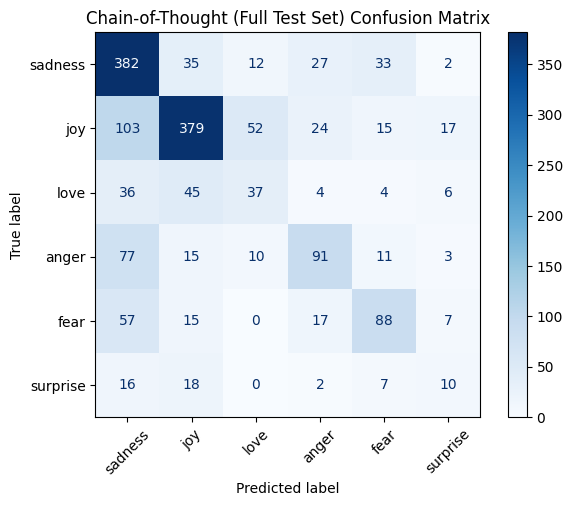

In [ ]:
import time
import re
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- 1. Setup Data & Tokenizer ---
test_data = dataset["test"] # Full 2,000 examples [cite: 37]
id_to_label = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}
label_to_id = {v: k for k, v in id_to_label.items()}

# Decoder models must pad on the left for batch generation
llm_tokenizer.padding_side = "left"
if llm_tokenizer.pad_token is None:
    llm_tokenizer.pad_token = llm_tokenizer.eos_token

batch_size = 32
test_loader = DataLoader(test_data, batch_size=batch_size)

true_labels_cot, predicted_labels_cot = [], []
example_prompts_cot, example_outputs_cot = [], []

print(f"🚀 Starting Full CoT Evaluation with Batch Size {batch_size}...")
start_time_cot = time.time()

# --- 2. Inference Loop ---
for batch in tqdm(test_loader, desc="CoT Progress"):
    texts = batch['text']
    labels = batch['label']

    # Build prompts
    prompts = [f"""<|system|>
You are an expert emotion classifier. Reason step-by-step then output the label on a new line starting with 'Final Emotion: ' followed by exactly one of: sadness, joy, love, anger, fear, or surprise.<|end|>
<|user|>
Text: "{text}"<|end|>
<|assistant|>""" for text in texts]

    # Tokenize batch
    inputs = llm_tokenizer(prompts, return_tensors="pt", padding=True, truncation=True).to("cuda")

    with torch.no_grad():
        outputs = llm_model.generate(
            **inputs,
            max_new_tokens=150, # Room for "thinking"
            temperature=0.1,
            do_sample=False,
            pad_token_id=llm_tokenizer.eos_token_id
        )

    input_length = inputs.input_ids.shape[1]

    for j in range(len(texts)):
        raw_output = llm_tokenizer.decode(outputs[j][input_length:], skip_special_tokens=True).strip()

        # Extract word after "Final Emotion:" [cite: 76]
        match = re.search(r"Final Emotion:\s*([a-zA-Z]+)", raw_output, re.IGNORECASE)
        extracted_word = match.group(1).lower() if match else raw_output.split()[-1].lower()
        clean_output = re.sub(r'[^\w\s]', '', extracted_word)

        pred_id = label_to_id.get(clean_output, -1)
        true_labels_cot.append(labels[j].item())
        predicted_labels_cot.append(pred_id)

        # Save first 3-5 examples for notebook requirements [cite: 79]
        if len(example_prompts_cot) < 5:
            example_prompts_cot.append(prompts[j])
            example_outputs_cot.append(raw_output)

inference_time_cot = time.time() - start_time_cot

# --- 3. Final Report & Visuals ---
print("\n" + "="*50)
print("1. EXAMPLE PROMPTS & RAW OUTPUTS [cite: 79]")
print("="*50)
for idx in range(len(example_prompts_cot)):
    print(f"\n[Example {idx+1}]\nPROMPT:\n{example_prompts_cot[idx]}")
    print(f"RAW OUTPUT:\n{example_outputs_cot[idx]}\n{'-'*30}")

print("\n" + "="*50)
print("2. FINAL METRICS [cite: 78, 81]")
print("="*50)
print(f"Total Inference Time: {inference_time_cot:.2f} seconds")
print(f"Accuracy: {accuracy_score(true_labels_cot, predicted_labels_cot):.4f}")
print(f"Macro F1: {f1_score(true_labels_cot, predicted_labels_cot, average='macro'):.4f}")

print("\n" + "="*50)
print("3. CONFUSION MATRIX [cite: 80]")
print("="*50)
cm = confusion_matrix(true_labels_cot, predicted_labels_cot, labels=[0, 1, 2, 3, 4, 5])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["sadness", "joy", "love", "anger", "fear", "surprise"])
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(cmap="Blues", xticks_rotation=45, ax=ax)
plt.title("Chain-of-Thought (Full Test Set) Confusion Matrix")
plt.show()

# Part 5 — Data Efficiency Experiment

In [ ]:
import pandas as pd
from datasets import Dataset

print("Constructing balanced training set...")

# 1. Convert the full training set to a Pandas DataFrame for easy manipulation
train_df = dataset["train"].to_pandas()

# 2. Define exactly how many samples we need from each class to br balanced
samples_per_class = {
    0: 84, # sadness
    1: 84, # joy
    2: 84, # love
    3: 84, # anger
    4: 84, # fear
    5: 84  # surprise
}

# 3. Sample the exact amounts and collect them
balanced_dfs = []
for label, n_samples in samples_per_class.items():
    class_df = train_df[train_df['label'] == label]
    # Use random_state=42 for reproducibility (so you get the same 500 every time)
    sampled_df = class_df.sample(n=n_samples, random_state=42)
    balanced_dfs.append(sampled_df)

# 4. Concatenate them all together and shuffle the deck
small_train_df = pd.concat(balanced_dfs).sample(frac=1, random_state=42).reset_index(drop=True)

# 5. Convert it back into a Hugging Face Dataset object
small_train_dataset = Dataset.from_pandas(small_train_df)

# --- Verification ---
print(f"\nSubset created successfully! Total examples: {len(small_train_dataset)}")
print("-" * 30)
print("Class Distribution:")
# Map the numbers back to words so it looks nice in your notebook output
id_to_label = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}
distribution = small_train_df['label'].map(id_to_label).value_counts()
print(distribution)

Constructing balanced training set...

Subset created successfully! Total examples: 504
------------------------------
Class Distribution:
label
love        84
anger       84
surprise    84
sadness     84
joy         84
fear        84
Name: count, dtype: int64


🚀 Retraining RNN from scratch on 500-sample subset...


RNN Epoch 1/5:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1 | Loss: 1.8010 | Train Acc: 0.1250


RNN Epoch 2/5:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 2 | Loss: 1.7713 | Train Acc: 0.2500


...

Epoch 3 | Loss: 1.7220 | Train Acc: 0.3492


RNN Epoch 4/5:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 4 | Loss: 1.5285 | Train Acc: 0.4206


RNN Epoch 5/5:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 5 | Loss: 1.2137 | Train Acc: 0.5595

Evaluating on full test set...

RNN (500 SAMPLES) FINAL RESULTS
Accuracy: 0.2525
Macro F1: 0.2183

Generating Comparison Plot...


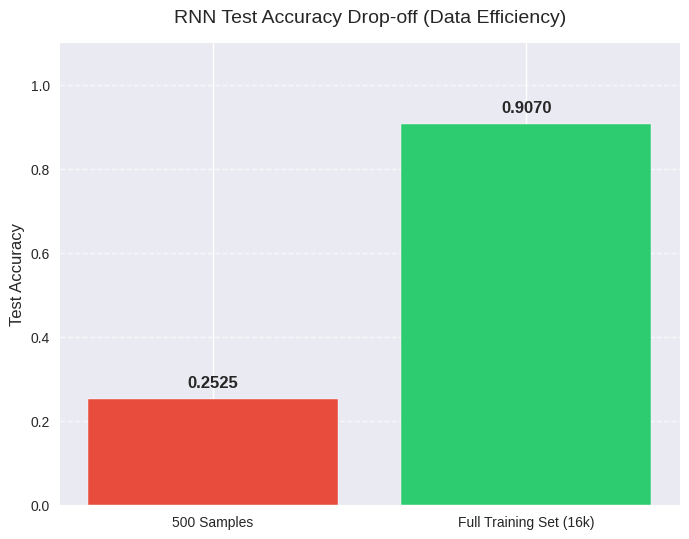

In [ ]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

print("🚀 Retraining RNN from scratch on 500-sample subset...")

# =========================================================
# 1. SETUP & RE-INITIALIZATION
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

rnn_model_small = EmotioanLSTM(
    vocab_size=len(rnn_vocab),
    embedding_dim=100,
    hidden_dim=128,
    output_dim=6,
    num_layers=2
).to(device)

optimizer_small = optim.Adam(rnn_model_small.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

# =========================================================
# 2. FIX: USE YOUR CUSTOM EmotionDataset CLASS!
# =========================================================
MAX_LEN = 64

# Wrap our tiny 500-sample dataset in your class
small_train_dataset_custom = EmotionDataset(small_train_dataset, rnn_vocab, max_len=MAX_LEN)
small_train_loader = DataLoader(small_train_dataset_custom, batch_size=16, shuffle=True)

# Wrap the full test set in your class
test_dataset_custom = EmotionDataset(dataset['test'], rnn_vocab, max_len=MAX_LEN)
test_loader = DataLoader(test_dataset_custom, batch_size=32, shuffle=False)

# =========================================================
# 3. TRAINING LOOP (5 Epochs)
# =========================================================
epochs = 5

for epoch in range(epochs):
    rnn_model_small.train()
    total_loss = 0
    correct_train = 0
    total_train = 0

    # FIX: Unpack the tuple directly, exactly how your EmotionDataset outputs it
    for texts, labels in tqdm(small_train_loader, desc=f"RNN Epoch {epoch+1}/{epochs}"):
        texts = texts.to(device)
        labels = labels.to(device)

        # Forward pass
        optimizer_small.zero_grad()
        predictions = rnn_model_small(texts)
        loss = criterion(predictions, labels)

        # Backward pass
        loss.backward()
        optimizer_small.step()

        total_loss += loss.item()

        # Calculate training accuracy
        _, predicted_classes = torch.max(predictions, 1)
        correct_train += (predicted_classes == labels).sum().item()
        total_train += labels.size(0)

    avg_loss = total_loss / len(small_train_loader)
    train_acc = correct_train / total_train
    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.4f}")

# =========================================================
# 4. EVALUATION ON FULL TEST SET
# =========================================================
rnn_model_small.eval()
rnn_preds = []
rnn_true = []

print("\nEvaluating on full test set...")
with torch.no_grad():
    for texts, labels in test_loader: # Unpack tuple here too!
        texts = texts.to(device)
        labels = labels.to(device)

        predictions = rnn_model_small(texts)
        predicted_classes = torch.argmax(predictions, dim=1)

        rnn_preds.extend(predicted_classes.cpu().numpy())
        rnn_true.extend(labels.cpu().numpy())

# =========================================================
# 5. FINAL METRICS & COMPARISON PLOT
# =========================================================
small_dataset_accuracy = accuracy_score(rnn_true, rnn_preds)
small_dataset_f1 = f1_score(rnn_true, rnn_preds, average='macro')

print("\n" + "="*50)
print("RNN (500 SAMPLES) FINAL RESULTS")
print("="*50)
print(f"Accuracy: {small_dataset_accuracy:.4f}")
print(f"Macro F1: {small_dataset_f1:.4f}")
print("="*50)

print("\nGenerating Comparison Plot...")


full_dataset_accuracy = 0.9070

# Prepare data for plotting
conditions = ['500 Samples', 'Full Training Set (16k)']
accuracies = [small_dataset_accuracy, full_dataset_accuracy]

# Create the bar plot
plt.figure(figsize=(8, 6))
bars = plt.bar(conditions, accuracies, color=['#e74c3c', '#2ecc71'])

# Add formatting and labels
plt.title('RNN Test Accuracy Drop-off (Data Efficiency)', fontsize=14, pad=15)
plt.ylabel('Test Accuracy', fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add the exact numbers on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()

🚀 Re-fine-tuning Transformer (Custom Loop) on 500-sample subset...


Map:   0%|          | 0/504 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Transformer Epoch 1/3:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1 | Average Training Loss: 1.7486


Transformer Epoch 2/3:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 2 | Average Training Loss: 1.3131


Transformer Epoch 3/3:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 3 | Average Training Loss: 0.9568

Evaluating on full test set...

TRANSFORMER (500 SAMPLES) FINAL RESULTS
Accuracy: 0.6095
Macro F1: 0.5977

Generating Comparison Plot...


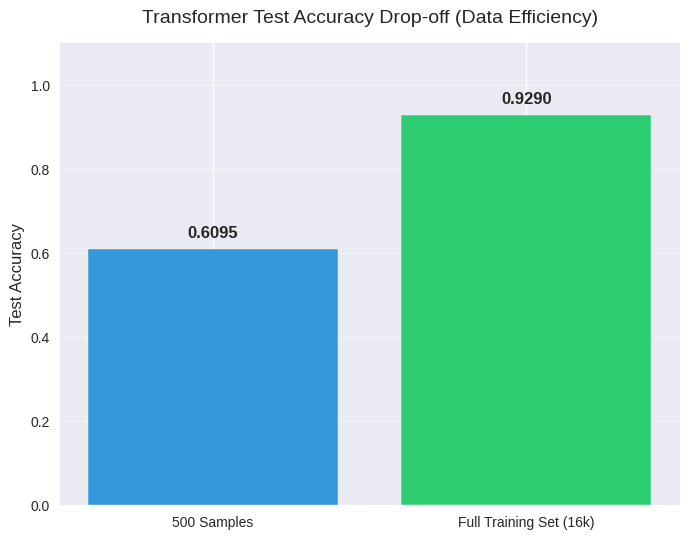

In [ ]:
import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

print("🚀 Re-fine-tuning Transformer (Custom Loop) on 500-sample subset...")

# =========================================================
# 1. TOKENIZE THE DATASETS
# =========================================================
model_name = "distilbert-base-uncased"
transformer_tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return transformer_tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=64,
    )

# Tokenize the tiny 500-sample train set and format for PyTorch
tokenized_small_train = small_train_dataset.map(tokenize_function, batched=True)
tokenized_small_train.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# Tokenize the full test set and format for PyTorch
tokenized_test = dataset["test"].map(tokenize_function, batched=True)
tokenized_test.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# =========================================================
# 2. CREATE DATALOADERS
# =========================================================
train_loader = DataLoader(tokenized_small_train, batch_size=16, shuffle=True)
test_loader = DataLoader(tokenized_test, batch_size=32)

# =========================================================
# 3. INITIALIZE A FRESH MODEL ON THE GPU
# =========================================================
# CRITICAL: We must load fresh pretrained weights to avoid using the Part 3 model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_small = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=6
).to(device)

# =========================================================
# 4. OPTIMIZER, SCHEDULER & LOSS FUNCTION
# =========================================================
epochs = 3
optimizer = AdamW(model_small.parameters(), lr=5e-5)
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

# =========================================================
# 5. CUSTOM TRAINING LOOP
# =========================================================
for epoch in range(epochs):
    model_small.train()
    total_train_loss = 0

    for batch in tqdm(train_loader, desc=f"Transformer Epoch {epoch+1}/{epochs}"):
        # Move batch to GPU
        b_input_ids = batch['input_ids'].to(device)
        b_input_mask = batch['attention_mask'].to(device)
        b_labels = batch['label'].to(device)

        # Clear previous gradients
        model_small.zero_grad()

        # Forward pass (outputs a tuple, we want the loss and logits)
        outputs = model_small(
            b_input_ids,
            attention_mask=b_input_mask,
            labels=b_labels
        )

        loss = outputs.loss
        total_train_loss += loss.item()

        # Backward pass
        loss.backward()

        # Clip the norm of the gradients to 1.0 (prevents exploding gradients)
        torch.nn.utils.clip_grad_norm_(model_small.parameters(), 1.0)

        # Update parameters
        optimizer.step()
        scheduler.step()

    avg_train_loss = total_train_loss / len(train_loader)
    print(f"Epoch {epoch+1} | Average Training Loss: {avg_train_loss:.4f}")

# =========================================================
# 6. EVALUATION ON FULL TEST SET
# =========================================================
model_small.eval()
transformer_preds = []
transformer_true = []

print("\nEvaluating on full test set...")
with torch.no_grad():
    for batch in test_loader:
        b_input_ids = batch['input_ids'].to(device)
        b_input_mask = batch['attention_mask'].to(device)
        b_labels = batch['label'].to(device)

        outputs = model_small(b_input_ids, attention_mask=b_input_mask)
        logits = outputs.logits

        # Move logits and labels to CPU
        logits = logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()

        # Calculate predictions
        preds = torch.argmax(torch.tensor(logits), dim=1).numpy()

        transformer_preds.extend(preds)
        transformer_true.extend(label_ids)

# =========================================================
# 7. FINAL METRICS & COMPARISON PLOT
# =========================================================
small_dataset_accuracy_transformer = accuracy_score(transformer_true, transformer_preds)
small_dataset_f1_transformer = f1_score(transformer_true, transformer_preds, average='macro')

print("\n" + "="*50)
print("TRANSFORMER (500 SAMPLES) FINAL RESULTS")
print("="*50)
print(f"Accuracy: {small_dataset_accuracy_transformer:.4f}")
print(f"Macro F1: {small_dataset_f1_transformer:.4f}")
print("="*50)

print("\nGenerating Comparison Plot...")


full_dataset_accuracy_transformer = 0.9290

conditions = ['500 Samples', 'Full Training Set (16k)']
accuracies = [small_dataset_accuracy_transformer, full_dataset_accuracy_transformer]

plt.figure(figsize=(8, 6))
bars = plt.bar(conditions, accuracies, color=['#3498db', '#2ecc71'])

plt.title('Transformer Test Accuracy Drop-off (Data Efficiency)', fontsize=14, pad=15)
plt.ylabel('Test Accuracy', fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()

The results show that pretraining dramatically improves data efficiency. While the from-scratch RNN’s accuracy dropped sharply from 90.7% to 25.3% when trained on only 500 examples, the pretrained transformer still achieved 60.9% accuracy under the same low-data setting. This demonstrates that pretrained models already contain useful linguistic knowledge learned from large-scale corpora, allowing them to generalize much better even with limited labeled data.

# Part 6 — Comparative Analysis

### 6.1 Performance Summary

The following table summarizes the performance of the three paradigms on the full test set:

| Metric | From-Scratch BiLSTM | Fine-Tuned DistilBERT | LLM (Zero-Shot Phi-3) |
| :--- | :---: | :---: | :---: |
| **Test Accuracy** | 90.70% | 92.90% | 51.50% |
| **Macro F1 Score** | 0.8706 | 0.8874 | 0.3720 |
| **Training Time** | ~1.43 mins | ~4.69 mins | N/A (No training) |
| **Inference Time (Test Set)** | 0.58s | 3.67s | 443.94s |

### 6.2 Efficiency and Failure Analysis

**Data Efficiency (Part 5 Results):**
*   **BiLSTM (From Scratch):** Suffered a massive performance drop when limited to 500 samples (dropping to ~25% accuracy). This highlights its total dependence on large labeled datasets to learn linguistic features from zero.
*   **DistilBERT (Fine-tuned):** Showed superior data efficiency, maintaining ~61% accuracy with only 500 samples. The pre-trained knowledge allows it to generalize well even when the downstream task data is scarce.

**Failure Modes (Confusion Matrix Insights):**
*   **BiLSTM:** Mostly struggled with the 'Surprise' class (F1: 0.76), often confusing it with 'Joy'. It also had some difficulty distinguishing 'Love' from 'Joy'.
*   **DistilBERT:** Most robust overall but shared the difficulty with 'Surprise' (F1: 0.75). It showed high precision in 'Sadness' but occasionally confused 'Love' and 'Joy'.
*   **LLM (Phi-3):** Significant confusion across the board. In Zero-Shot and Few-Shot, it struggled to adhere strictly to the label set and often defaulted to 'Sadness' or 'Joy' for ambiguous text, showing poor alignment with the specific nuances of this dataset's labels.

### 6.3 Strategic Recommendations

**When to choose each paradigm:**

1.  **Fine-Tuned Transformers (e.g., DistilBERT):** This is the best choice for most real-world classification projects. It offers the highest accuracy and best data efficiency. Choose this when you have at least a few hundred labeled examples and need a production-ready model that is fast enough for real-time use.
2.  **From-Scratch RNNs (e.g., BiLSTM):** Choose this primarily for educational purposes or extremely niche domains where pre-trained models don't exist and you have an enormous amount of data. In modern NLP, they are largely superseded by Transformers due to their lower performance and poor data efficiency.
3.  **LLM Prompting (Zero/Few-Shot):** Choose this for rapid prototyping, cold-start scenarios where you have zero labeled data, or when the task is extremely complex (e.g., reasoning required). However, for simple classification, they are currently too slow and less accurate than smaller, fine-tuned models.